Name: Shubhajeet Das <br />
Roll No.: 24AI10013 <br />
DL Lab Assignment 7 -> Number plate detection

# Real-Time Object Detection Using Custom Dataset (YOLO vs Faster R-CNN From Scratch)
## Problem Statement

Design a real-time object detection system that detects **Number plate**

In [1]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
print(os.listdir())

cuda
['.idea', '.ipynb_checkpoints', '.venv', '.vscode', '24AI10013', '24AI10013_DLDL', '24AI10013_Shubhajeet_10022026', '24AI10013_Shubhajeet_13JAN2026', '24AI10013_Shubhajeet_20012026', 'cnn.py', 'data', 'demo.ipynb', 'demo_6.pdf', 'dl1.py', 'dl_lab_assgn.ipynb', 'kaggle_digit_recog', 'kaggle_dog', 'loading_models.ipynb', 'models', 'New folder', 'practice01.py', 'test.ipynb', 'test1.ipynb', 'yolo_assgn.ipynb']


## Utility functions

In [2]:
def compute_iou(box1, box2):
    """box format: [x1, y1, x2, y2]"""

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_area = max(0, x2 - x1) * max(0, y2 - y1)

    box1_area = (box1[2]-box1[0])*(box1[3]-box1[1])
    box2_area = (box2[2]-box2[0])*(box2[3]-box2[1])

    union = box1_area + box2_area - inter_area

    return inter_area / (union + 1e-6)

In [3]:
def non_max_suppression(boxes, scores, threshold=0.5):
    indices = scores.argsort(descending=True)
    keep = []

    while indices.numel() > 0:
        current = indices[0]
        keep.append(current)

        if indices.numel() == 1:
            break

        rest = indices[1:]
        ious = torch.tensor([
            compute_iou(boxes[current], boxes[i]) for i in rest
        ])

        indices = rest[ious < threshold]

    return keep

In [4]:
def mask_to_bbox(mask):
    mask = np.array(mask)
    coords = np.column_stack(np.where(mask > 0))
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return [x_min, y_min, x_max, y_max]

In [5]:
def detection_loss(pred, target_bbox):
    """
    pred: [x1,y1,x2,y2,conf]
    target_bbox: [x1,y1,x2,y2]
    """
    bbox_pred = pred[:4]
    conf_pred = torch.sigmoid(pred[4])

    bbox_loss = nn.functional.mse_loss(bbox_pred, target_bbox)

    iou = compute_iou(
        bbox_pred.detach().cpu().numpy(),
        target_bbox.detach().cpu().numpy()
    )

    conf_target = torch.tensor(iou).to(device)

    conf_loss = nn.functional.mse_loss(conf_pred, conf_target)

    return bbox_loss + conf_loss

In [6]:
from tqdm import tqdm
os.makedirs("./models", exist_ok=True)
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
def train_model_yolo(model, train_loader, val_loader, optimizer=None, verbose=True):
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)
    # assuming model already in cuda device
    n_total_steps = len(train_loader)
    epochs = []
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    for epoch in tqdm(range(NUM_EPOCHS)):
        train_loss = 0.
        val_loss = 0.
        model.train()
        for i, (images, masks) in enumerate(train_loader):
            images = images.to(device)
            bboxs = mask_to_bbox(masks)
            bboxs = torch.tensor(bboxs, dtype=torch.float32).to(device)
            preds = model(images).squeeze()
            loss = detection_loss(preds, bboxs)
            batch_size = masks.size(0)
            train_loss += loss.item() * batch_size
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if verbose and (i + 1) % 50 == 0:
                print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}")
        train_loss /= len(train_loader.dataset)
        epochs.append(epoch + 1)
        train_losses.append(train_loss)
        model.eval()
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                bboxs = mask_to_bbox(masks)
                bboxs = torch.tensor(bboxs, dtype=torch.float32).to(device)
                preds = model(images).squeeze()
                loss = detection_loss(preds, bboxs)
                batch_size = masks.size(0)
                val_loss += loss.item() * batch_size
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        if verbose:
	        print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}], Train loss {train_loss:.4f}, Val loss {val_loss:.4f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'model_state_dict' : model.state_dict(),
                'optimizer_state_dict' : optimizer.state_dict()
            }, f"./models/Epoch{epoch+1}.pth")
            if verbose:
	            print("Saved best model")

    if verbose:
	    print("Finished training")
    plt.plot(epochs, train_losses, label="Train Loss", marker="o")
    plt.plot(epochs, val_losses, label="Val Loss", marker="o")
    plt.legend()
    plt.show()

In [7]:
from tqdm import tqdm
os.makedirs("./models", exist_ok=True)
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3

def train_model_rcnn(model, train_loader, val_loader, optimizer=None, verbose=True):
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    n_total_steps = len(train_loader)
    epochs, train_losses, val_losses = [], [], []
    best_val_loss = float("inf")

    for epoch in tqdm(range(NUM_EPOCHS)):
        train_loss = 0.0
        val_loss = 0.0
        model.train()

        for i, (images, targets) in enumerate(train_loader):
            images = [img.to(device) for img in images]
            # --- robust target handling ---
            if isinstance(targets, torch.Tensor):
                targets = targets.to(device)
            elif isinstance(targets, (list, tuple)):
                processed = []
                for t in targets:
                    if isinstance(t, torch.Tensor):
                        processed.append(t.to(device))
                    elif isinstance(t, dict):
                        processed.append({k: v.to(device) for k, v in t.items()})
                    else:
                        try:
                            processed.append(t.to(device))
                        except Exception:
                            processed.append(t)
                targets = processed
            else:
                try:
                    targets = targets.to(device)
                except Exception:
                    pass
            # --------------------------------

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            batch_size = targets.size(0) if isinstance(targets, torch.Tensor) else len(targets)
            train_loss += losses.item() * batch_size

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            if verbose and (i + 1) % 50 == 0:
                print(
                    f"Epoch [{epoch+1}/{NUM_EPOCHS}], "
                    f"Step [{i+1}/{n_total_steps}], "
                    f"Loss: {losses.item():.4f}"
                )

        train_loss /= len(train_loader.dataset)
        epochs.append(epoch + 1)
        train_losses.append(train_loss)

        # model.eval()
        with torch.no_grad():
            for images, targets in val_loader:
                images = [img.to(device) for img in images]
                # same handling as above…
                if isinstance(targets, torch.Tensor):
                    targets = targets.to(device)
                elif isinstance(targets, (list, tuple)):
                    processed = []
                    for t in targets:
                        if isinstance(t, torch.Tensor):
                            processed.append(t.to(device))
                        elif isinstance(t, dict):
                            processed.append({k: v.to(device) for k, v in t.items()})
                        else:
                            try:
                                processed.append(t.to(device))
                            except Exception:
                                processed.append(t)
                    targets = processed
                else:
                    try:
                        targets = targets.to(device)
                    except Exception:
                        pass

                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
                batch_size = targets.size(0) if isinstance(targets, torch.Tensor) else len(targets)
                val_loss += losses.item() * batch_size

        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        if verbose:
            print(
                f"Epoch [{epoch + 1}/{NUM_EPOCHS}], Train loss {train_loss:.4f}, Val loss {val_loss:.4f}"
            )
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                },
                f"./models/Epoch{epoch+1}.pth",
            )
            if verbose:
                print("Saved best model")

    if verbose:
        print("Finished training")

    plt.plot(epochs, train_losses, label="Train Loss", marker="o")
    plt.plot(epochs, val_losses, label="Val Loss", marker="o")
    plt.legend()
    plt.show()


## Data Preparation

### Load the Dataset

In [8]:
try:
    import kagglehub
    # Download latest version
    path = kagglehub.dataset_download("pkdarabi/helmet")
except ImportError:
    print("kagglehub not installed; we have to download the dataset manually and set 'path' accordingly.")
    path = r"C:\path\to\HelmetViolations"  # update this to local copy

print("Path to dataset files:", path)

C:\Users\shubh\micromamba\envs\pytorch-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|███████████████████████████████████████████████████████████████████████████████| 202M/202M [00:27<00:00, 7.59MB/s]

Extracting files...


Path to dataset files: C:\Users\shubh\.cache\kagglehub\datasets\pkdarabi\helmet\versions\4


In [9]:
print(os.listdir(path))

['22.mp4', 'best.pt', 'HelmetViolations', 'HelmetViolationsV2']


### Perform train/val/test split (70/20/10)

In [10]:
import shutil
data_root = os.path.join(path, "HelmetViolations")
# collect all image/label pairs from the original splits
subdirs = ["train", "val", "test"]
pairs = []
for sd in subdirs:
    img_dir = os.path.join(data_root, sd, "images")
    lbl_dir = os.path.join(data_root, sd, "labels")
    if not os.path.isdir(img_dir):
        continue
    for fname in os.listdir(img_dir):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(img_dir, fname)
            lbl_name = os.path.splitext(fname)[0] + ".txt"
            lbl_path = os.path.join(lbl_dir, lbl_name)
            if os.path.exists(lbl_path):
                pairs.append((img_path, lbl_path))
print(f"Found {len(pairs)} labelled images in original splits.")
random.shuffle(pairs)
n = len(pairs)
n_train = int(0.7 * n)
n_val = int(0.2 * n)
splits = {
    "train": pairs[:n_train],
    "val": pairs[n_train:n_train + n_val],
    "test": pairs[n_train + n_val:],
}
# create output directories
split_root = os.path.join(data_root, "split70_20_10")
for split in splits:
    for sub in ["images", "labels"]:
        os.makedirs(os.path.join(split_root, split, sub), exist_ok=True)
# copy the files to the new structure
for split, items in splits.items():
    for img_path, lbl_path in items:
        dst_img = os.path.join(split_root, split, "images", os.path.basename(img_path))
        dst_lbl = os.path.join(split_root, split, "labels", os.path.basename(lbl_path))
        shutil.copy(img_path, dst_img)
        shutil.copy(lbl_path, dst_lbl)
print("New split created under", split_root)

Found 903 labelled images in original splits.
New split created under C:\Users\shubh\.cache\kagglehub\datasets\pkdarabi\helmet\versions\4\HelmetViolations\split70_20_10


### Apply augmentation:

- Horizontal flip

- Brightness change

- Scaling

- Random crop

In [11]:
from torchvision.transforms import v2
from torchvision import tv_tensors
import cv2
class YOLODataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, label_dir, transform=None, img_size=(640, 640)):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.img_size = img_size
        self.img_files = sorted([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]
        label_path = os.path.join(self.label_dir, self.img_files[idx].rsplit('.', 1)[0] + '.txt')
        with open(label_path, 'r') as f:
            line = f.readline().split()
            if len(line) >= 5:
                _, xc, yc, nw, nh = map(float, line)
        x1 = (xc - nw / 2) * w
        y1 = (yc - nh / 2) * h
        x2 = (xc + nw / 2) * w
        y2 = (yc + nh / 2) * h
        image = tv_tensors.Image(image.transpose(2, 0, 1))
        bboxes = tv_tensors.BoundingBoxes(
            [[x1, y1, x2, y2]],
            format="XYXY",
            canvas_size=(h, w) 
        )
        image, bboxes = self.transform(image, bboxes)
        return image, bboxes.squeeze()

In [12]:
class RCNNDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, label_dir, transform=None, img_size=(640, 640)):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.img_size = img_size
        self.img_files = sorted([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]
        label_path = os.path.join(self.label_dir, self.img_files[idx].rsplit('.', 1)[0] + '.txt')
        with open(label_path, 'r') as f:
            line = f.readline().split()
            if len(line) >= 5:
                _, xc, yc, nw, nh = map(float, line)
        x1 = (xc - nw / 2) * w
        y1 = (yc - nh / 2) * h
        x2 = (xc + nw / 2) * w
        y2 = (yc + nh / 2) * h
        image = tv_tensors.Image(image.transpose(2, 0, 1))
        bboxes = tv_tensors.BoundingBoxes(
            [[x1, y1, x2, y2]],
            format="XYXY",
            canvas_size=(h, w) 
        )
        image, bboxes = self.transform(image, bboxes)
        bboxes = torch.as_tensor(bboxes).float()
        bboxes[:, 0].clamp_(0, w-1)
        bboxes[:, 1].clamp_(0, h-1)
        bboxes[:, 2].clamp_(0, w-1)
        bboxes[:, 3].clamp_(0, h-1)
        bad = (bboxes[:, 2] <= bboxes[:, 0]) | (bboxes[:, 3] <= bboxes[:, 1])
        if bad.any():
            bboxes = bboxes[~bad]
        if bboxes.numel() == 0:
            bboxes = torch.tensor([[0.0,0.0,1.0,1.0]])
        if isinstance(bboxes, tv_tensors.BoundingBoxes):
            bboxes = bboxes.squeeze()
        bboxes = torch.as_tensor(bboxes)
        if bboxes.ndim == 1:
            bboxes = bboxes.unsqueeze(0)
        target = {}
        target["boxes"]  = bboxes
        target["labels"] = torch.tensor([1], dtype=torch.long)
        return image, target

In [13]:
from torchvision.transforms import v2
from torchvision import tv_tensors
transform = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.ColorJitter(brightness=0.2, contrast=0.2),
    v2.RandomAffine(degrees=0, scale=(0.8, 1.2)), 
    v2.RandomCrop(size=(416, 416), pad_if_needed=True),
    v2.Resize(size=(600, 800)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
    # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
IMG_SIZE = (800, 600)
train_dataset = YOLODataset('C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/train/images', 'C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/train/labels', transform=transform, img_size=IMG_SIZE)
val_dataset   = YOLODataset('C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/val/images',   'C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/val/labels',   transform=transform, img_size=IMG_SIZE)
test_dataset  = YOLODataset('C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/test/images',  'C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/test/labels',  transform=transform, img_size=IMG_SIZE)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=1, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=1, shuffle=False)
print("Transformations applied and Dataloaders created")

Transformations applied and Dataloaders created


In [14]:
def collate_fn(batch):
    return tuple(zip(*batch))
train_rcnn_dataset = RCNNDataset('C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/train/images', 'C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/train/labels', transform=transform, img_size=IMG_SIZE)
val_rcnn_dataset   = RCNNDataset('C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/val/images',   'C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/val/labels',   transform=transform, img_size=IMG_SIZE)
test_rcnn_dataset  = RCNNDataset('C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/test/images',  'C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/test/labels',  transform=transform, img_size=IMG_SIZE)

train_rcnn_loader = torch.utils.data.DataLoader(train_rcnn_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)
val_rcnn_loader   = torch.utils.data.DataLoader(val_rcnn_dataset,   batch_size=1, shuffle=False, collate_fn=collate_fn)
test_rcnn_loader  = torch.utils.data.DataLoader(test_rcnn_dataset,  batch_size=1, shuffle=False, collate_fn=collate_fn)
print("Dataloaders for rcnn created")

Dataloaders for rcnn created


### Plot:

- Class distribution

- Bounding box size distribution

Processing Test: 100%|████████████████████████████████████████████████████████████████| 91/91 [00:00<00:00, 526.55it/s]


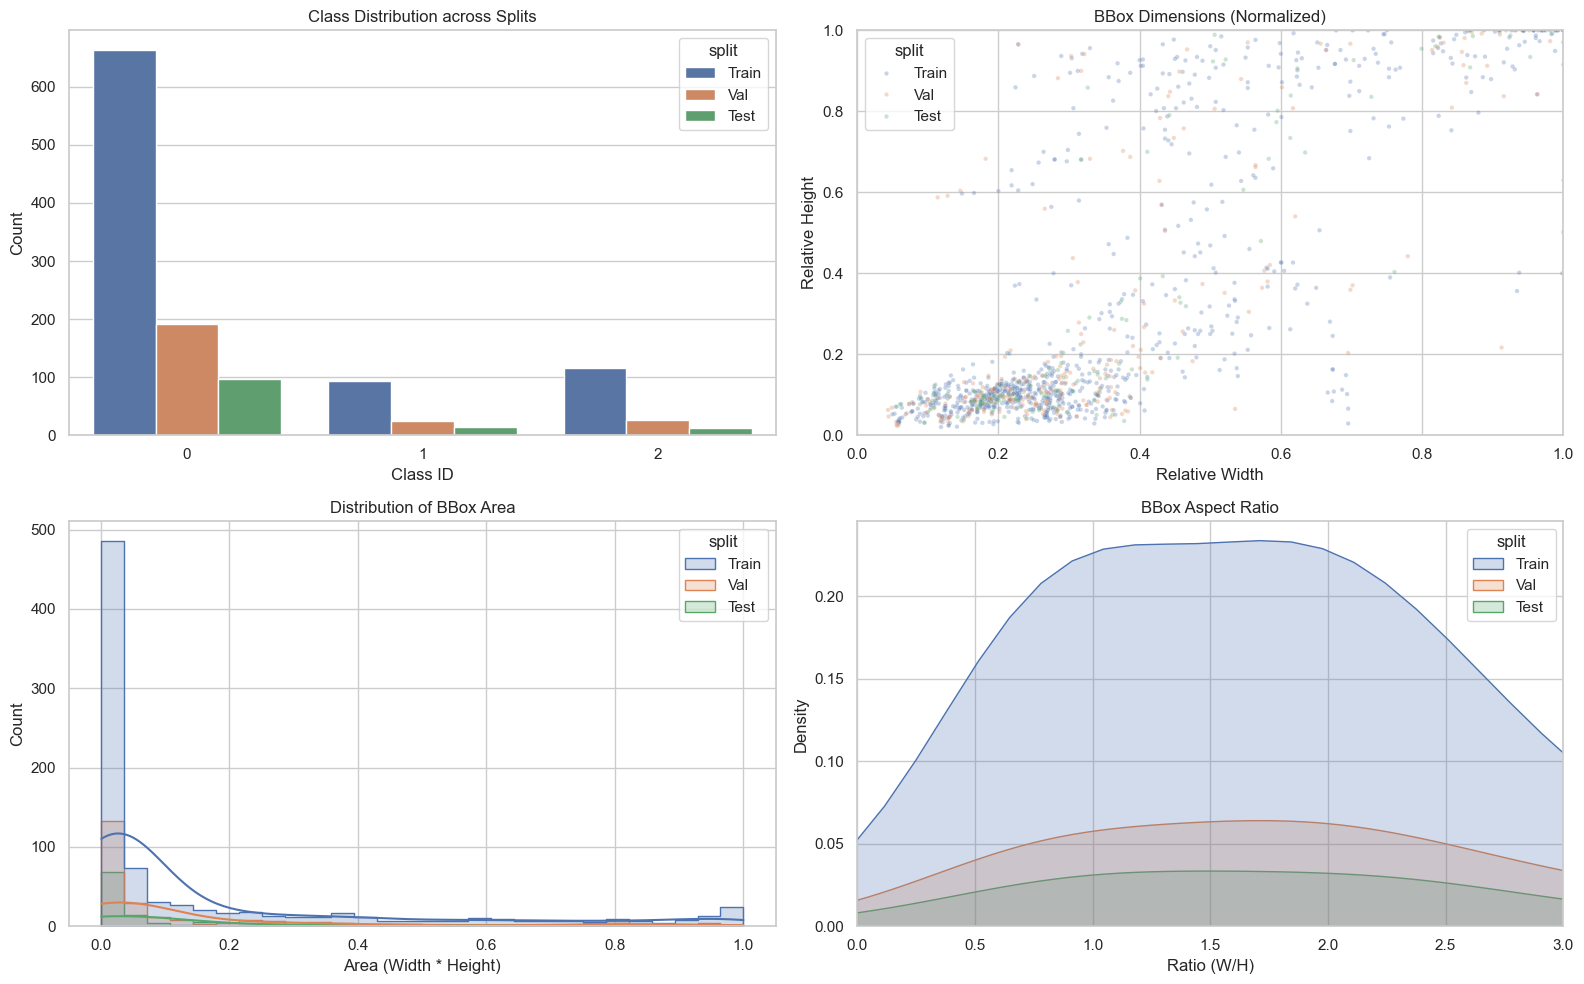

In [15]:
import glob
def analyze_yolo_dataset(label_paths, split_name="Train"):
    data = []
    label_files = glob.glob(os.path.join(label_paths, "*.txt"))
    for file in tqdm(label_files, desc=f"Processing {split_name}"):
        with open(file, 'r') as f:
            for line in f.readlines():
                parts = line.split()
                if len(parts) == 5:
                    class_id, xc, yc, w, h = map(float, parts)
                    data.append({
                        'split': split_name,
                        'class_id': int(class_id),
                        'width': w,
                        'height': h,
                        'area': w * h
                    })
    return pd.DataFrame(data)

train_df = analyze_yolo_dataset('C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/train/labels', "Train")
val_df = analyze_yolo_dataset('C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/val/labels', "Val")
test_df = analyze_yolo_dataset('C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/test/labels', "Test")

df = pd.concat([train_df, val_df, test_df])

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))

# --- Plot 1: Class Distribution ---
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='class_id', hue='split')
plt.title('Class Distribution across Splits')
plt.xlabel('Class ID')
plt.ylabel('Count')

# --- Plot 2: Bounding Box Size Scatter (Width vs Height) ---
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='width', y='height', hue='split', alpha=0.3, s=10)
plt.title('BBox Dimensions (Normalized)')
plt.xlabel('Relative Width')
plt.ylabel('Relative Height')
plt.xlim(0, 1)
plt.ylim(0, 1)

# --- Plot 3: BBox Area Distribution ---
plt.subplot(2, 2, 3)
sns.histplot(data=df, x='area', hue='split', kde=True, element="step")
plt.title('Distribution of BBox Area')
plt.xlabel('Area (Width * Height)')

# --- Plot 4: Aspect Ratio (Width / Height) ---
df['aspect_ratio'] = df['width'] / df['height']
plt.subplot(2, 2, 4)
sns.kdeplot(data=df, x='aspect_ratio', hue='split', fill=True)
plt.title('BBox Aspect Ratio')
plt.xlabel('Ratio (W/H)')
plt.xlim(0, 3)

plt.tight_layout()
plt.show()

In [16]:
def merge_yolo_labels(root_dirs, target_map):
    # to merge labels 1 and 2
    for folder in root_dirs:
        print(f"Processing folder: {folder}")
        label_files = glob.glob(os.path.join(folder, "*.txt"))
        for file_path in tqdm(label_files):
            updated_lines = []
            has_changes = False
            with open(file_path, 'r') as f:
                lines = f.readlines()
            for line in lines:
                parts = line.split()
                if not parts:
                    continue
                class_id = int(parts[0])
                if class_id in target_map:
                    parts[0] = str(target_map[class_id])
                    has_changes = True
                updated_lines.append(" ".join(parts) + "\n")
            if has_changes:
                with open(file_path, 'w') as f:
                    f.writelines(updated_lines)

label_paths = ['C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/train/labels', 'C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/val/labels', 'C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/test/labels']
mapping = {2: 1}  # Change class 2 -> class 1

merge_yolo_labels(label_paths, mapping)
print("Merge complete!")

Processing folder: C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/train/labels


100%|██████████████████████████████████████████████████████████████████████████████| 632/632 [00:00<00:00, 5447.00it/s]


Processing folder: C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/val/labels


100%|██████████████████████████████████████████████████████████████████████████████| 180/180 [00:00<00:00, 5080.79it/s]


Processing folder: C:/Users/shubh/.cache/kagglehub/datasets/pkdarabi/helmet/versions/4/HelmetViolations/split70_20_10/test/labels


100%|████████████████████████████████████████████████████████████████████████████████| 91/91 [00:00<00:00, 5585.69it/s]

Merge complete!


### Deliver:

- Atleast 3 annotated samples

- Histogram plots

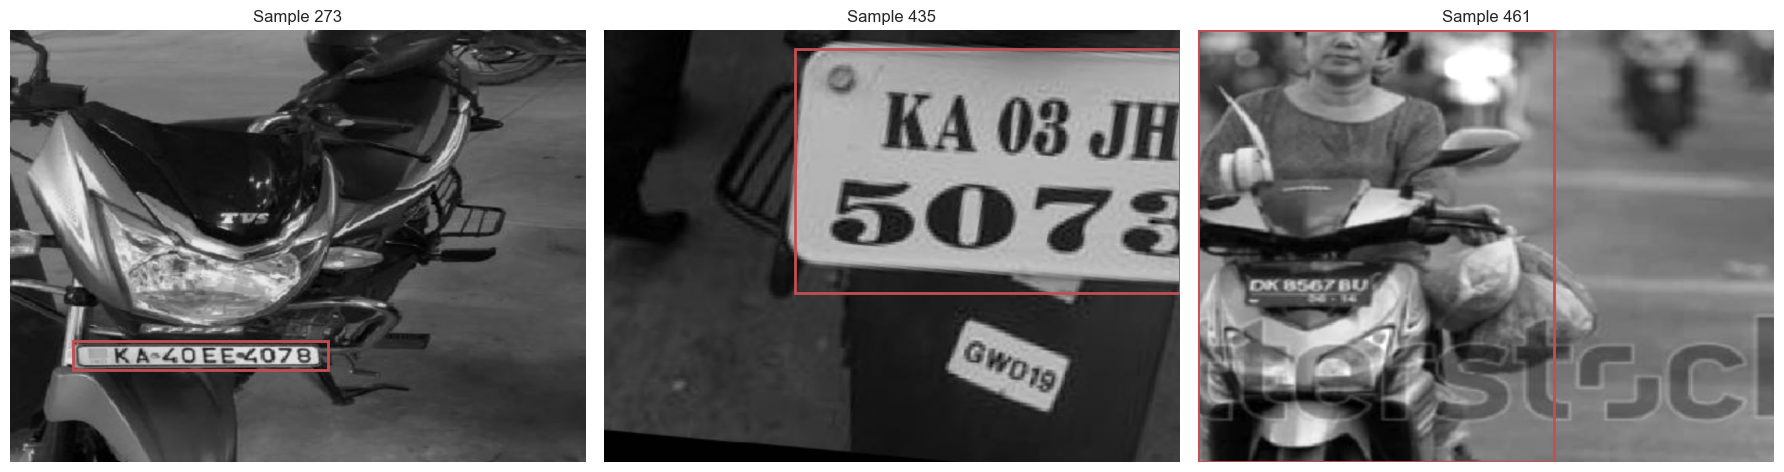

Histogram plots were already generated in the previous cell.


In [17]:
import matplotlib.patches as patches
import cv2
def show_annotated_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(1, num_samples, figsize=(18, 6))
    for i in range(num_samples):
        idx = random.randint(0, len(dataset) - 1)
        image, bbox = dataset[idx]
        img_np = image.permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0, 1)
        x1, y1, x2, y2 = bbox.numpy()
        axes[i].imshow(img_np)
        
        # Create a Rectangle patch: (x, y), width, height
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1, 
            linewidth=2, edgecolor='r', facecolor='none'
        )
        axes[i].add_patch(rect)
        axes[i].set_title(f"Sample {idx}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

show_annotated_samples(train_dataset, num_samples=3)
print('Histogram plots were already generated in the previous cell.')

## YOLO

### Implement:

Custom CNN backbone

Grid-based detection head

Bounding box regression

Objectness score

Class prediction

IoU calculation

In [18]:
class SimpleYOLODetector(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((16, 16))
        )

        self.flatten = nn.Flatten()

        self.head = nn.Sequential(
            nn.Linear(64*16*16, 256),
            nn.ReLU(),
            nn.Linear(256, 5)
            # 4 bbox coords + 1 confidence
        )

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.head(x)
        return x
model_yolo = SimpleYOLODetector().to(device)

  0%|                                                                                           | 0/20 [00:00<?, ?it/s]C:\Users\shubh\AppData\Local\Temp\ipykernel_32064\3660042470.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  mask = np.array(mask)
100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [07:28<00:00, 22.40s/it]


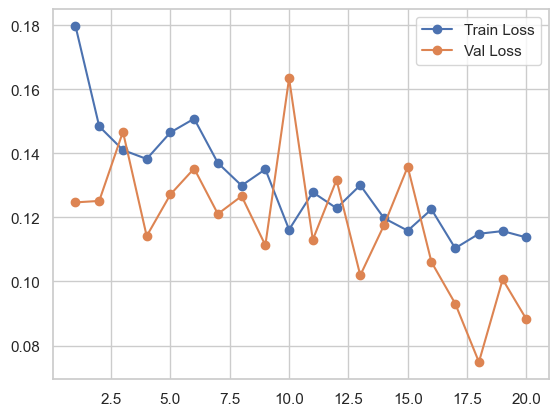

In [19]:
train_model_yolo(model_yolo, train_loader, val_loader, verbose=False)

## Faster R-CNN

### Implement

* CNN backbone

* Anchor generator

* Region Proposal Network (RPN)

* IoU-based anchor labeling

* ROI Pooling

* Classification head

* Bounding box regression head

* NMS

In [20]:
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator

class CustomCNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.out_channels = 64 

    def forward(self, x):
        x = self.features(x)
        return {"0": x}

def get_simple_faster_rcnn(num_classes=2):
    """
    num_classes: includes the background! 
    If we have 1 object class (e.g., 'dog'), num_classes should be 2.
    """
    backbone = CustomCNNBackbone()
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )
    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )
    
    return model

model_frcnn = get_simple_faster_rcnn(num_classes=3).to(device)
print("Faster RCNN model initialised")

Faster RCNN model initialised


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [12:03<00:00, 36.19s/it]


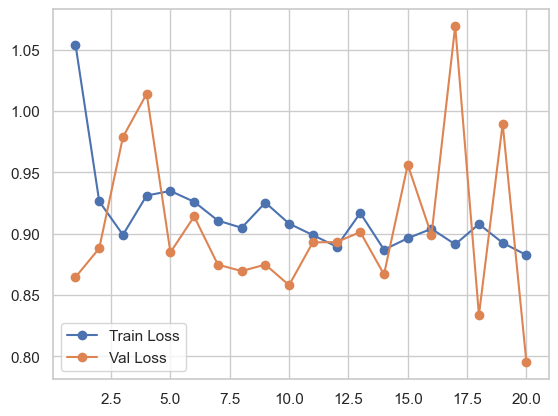

In [21]:
train_model_rcnn(model_frcnn, train_rcnn_loader, val_rcnn_loader, verbose=False)

## Quantitative Evaluation

### Compute:
- Precision
- Recall
- AP
- mAP@0.5

In [22]:
import time
from torchmetrics.detection.mean_ap import MeanAveragePrecision
def get_model_size(model):
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
    size_all_mb = (param_size + buffer_size) / 1024**2
    return size_all_mb

@torch.no_grad()
def evaluate_model(model, dataloader, device, model_type="yolo"):
    model.eval()
    metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox', extended_summary=True)
    ious = []
    latencies = []
    all_preds = []
    all_targets = []

    for images, targets in dataloader:
        if model_type == "yolo":
            # YOLO loader returns (Tensor, Tensor)
            images = images.to(device)
            target_bboxes = targets.to(device) 
        else:
            # RCNN loader returns (List[Tensor], List[Dict])
            images = list(img.to(device) for img in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Start Latency Timer
        start_time = time.perf_counter()
        outputs = model(images)
        latencies.append(time.perf_counter() - start_time)

        # Process Outputs for Metric
        preds_processed = []
        targets_processed = []

        if model_type == "yolo":
            if outputs.ndim == 1:
                outputs = outputs.unsqueeze(0)
            for i in range(images.shape[0]):
                out = outputs[i]
                preds_processed.append({
                    "boxes": out[:4].unsqueeze(0),
                    "scores": torch.sigmoid(out[4]).unsqueeze(0),
                    "labels": torch.tensor([1]).to(device)
                })
                targets_processed.append({
                    "boxes": target_bboxes[i].unsqueeze(0)
                              if target_bboxes.ndim > 1
                              else target_bboxes.unsqueeze(0),
                    "labels": torch.tensor([1]).to(device)
                })
        else:
            # Faster R-CNN already returns List[Dict{"boxes", "labels", "scores"}]
            preds_processed = outputs
            targets_processed = targets

        metric.update(preds_processed, targets_processed)
        
        # Calculate IoU for distribution
        for p, t in zip(preds_processed, targets_processed):
            if p['boxes'].shape[0] > 0:
                iou = torchvision.ops.box_iou(p['boxes'], t['boxes'])
                ious.append(iou.max().item())

    # Compute Final Metrics
    results = metric.compute()
    avg_latency = np.mean(latencies)
    fps = 1 / avg_latency
    
    print(f"\n--- {model_type.upper()} Evaluation ---")
    print(f"mAP@0.5: {results['map_50']:.4f}")
    print(f"mAP@0.5:0.95: {results['map']:.4f}")
    print(f"Latency: {avg_latency*1000:.2f}ms | FPS: {fps:.2f}")
    print(f"Model Size: {get_model_size(model):.2f} MB")
    
    return results, ious, metric

In [23]:
results_yolo, ious_yolo, metric_yolo = evaluate_model(model_yolo, test_loader, device, "yolo")
results_rcnn, ious_rcnn, metric_rcnn = evaluate_model(model_frcnn, test_rcnn_loader, device, "rcnn")


--- YOLO Evaluation ---
mAP@0.5: 0.0000
mAP@0.5:0.95: 0.0000
Latency: 1.36ms | FPS: 734.66
Model Size: 16.10 MB

--- RCNN Evaluation ---
mAP@0.5: 0.4961
mAP@0.5:0.95: 0.2308
Latency: 14.34ms | FPS: 69.75
Model Size: 16.56 MB


In [29]:
max_recall_class_0 = results_yolo['recall'][0, 0, 0, -1]
avg_max_recall = results_yolo['recall'][0, :, 0, -1].mean()
print(f"Max Recall at IoU=0.5: {avg_max_recall:.4f}")

Max Recall at IoU=0.5: 0.0000


In [30]:
max_recall_class_0 = results_rcnn['recall'][0, 0, 0, -1]
avg_max_recall = results_rcnn['recall'][0, :, 0, -1].mean()
print(f"Max Recall at IoU=0.5: {avg_max_recall:.4f}")

Max Recall at IoU=0.5: 0.6374


### Plot Precision–Recall curve

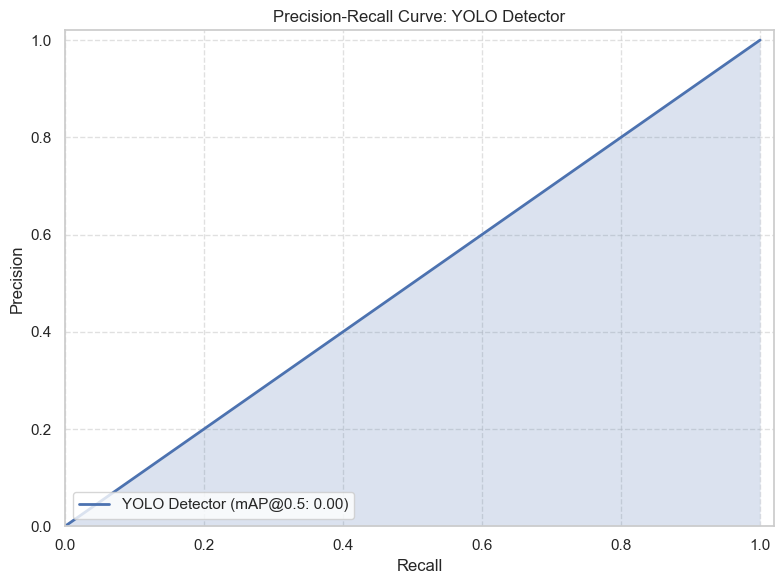

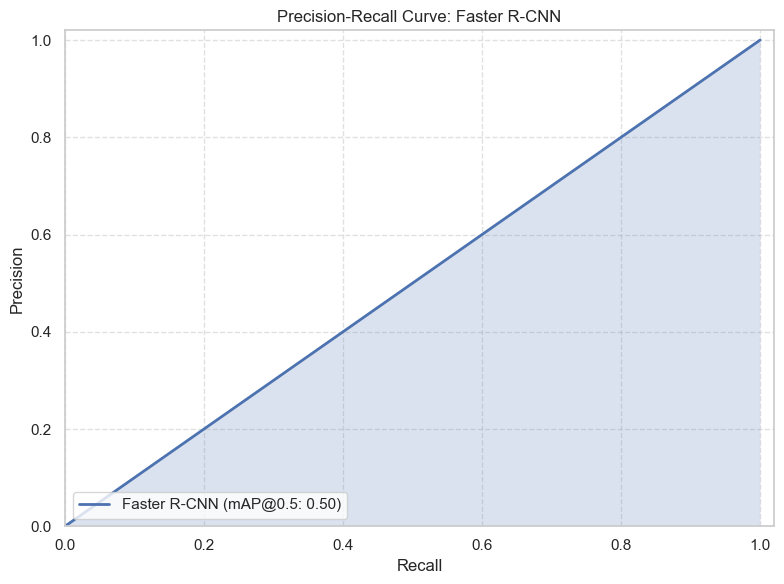

In [24]:
def plot_precision_recall_manual(results, ious, model_name="Model"):
    sorted_ious = np.sort(ious)[::-1]
    total_gt = len(ious)
    precisions = []
    recalls = []
    
    for threshold in np.linspace(0, 1, 101):
        tp = np.sum(sorted_ious >= threshold)
        fp = np.sum(sorted_ious < threshold)
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / total_gt if total_gt > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
    
    precisions = np.array(precisions)
    recalls = np.array(recalls)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recalls, precisions, label=f'{model_name} (mAP@0.5: {results["map_50"]:.2f})', linewidth=2)
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve: {model_name}')
    plt.legend(loc='lower left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim([0, 1.02])
    plt.ylim([0, 1.02])
    plt.fill_between(recalls, precisions, alpha=0.2)
    plt.tight_layout()
    plt.show()

plot_precision_recall_manual(results_yolo, ious_yolo, model_name="YOLO Detector")
plot_precision_recall_manual(results_rcnn, ious_rcnn, model_name="Faster R-CNN")

### Plot IoU distribution histogram.

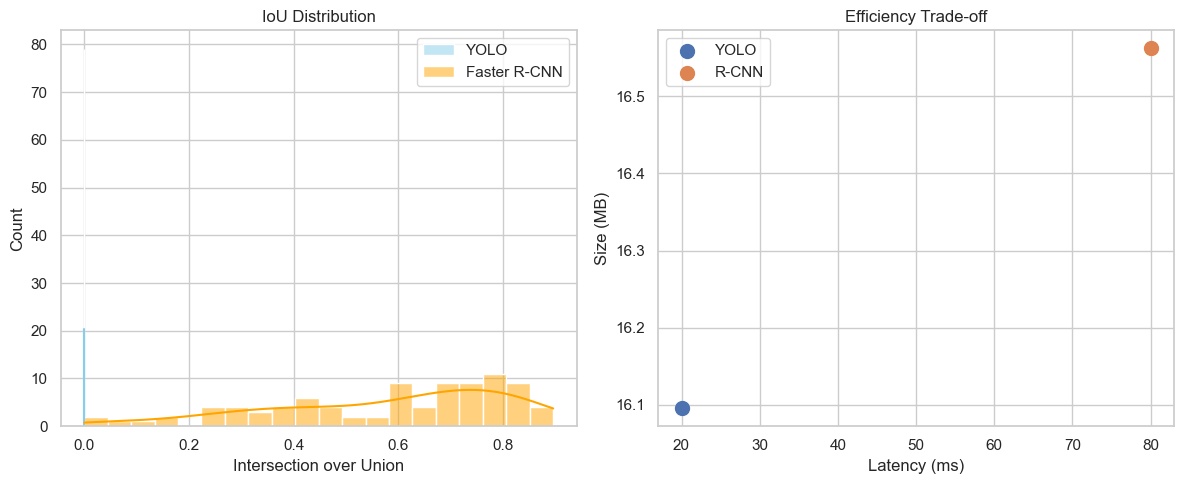

In [25]:
def plot_comparisons(ious_yolo, ious_rcnn):
    plt.figure(figsize=(12, 5))

    # IoU Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(ious_yolo, color="skyblue", label="YOLO", kde=True, bins=20)
    sns.histplot(ious_rcnn, color="orange", label="Faster R-CNN", kde=True, bins=20)
    plt.title("IoU Distribution")
    plt.xlabel("Intersection over Union")
    plt.legend()

    # Model Size vs Latency Scatter
    plt.subplot(1, 2, 2)
    # Placeholder values for demonstration - replace with actual vars
    plt.scatter([20], [get_model_size(model_yolo)], label="YOLO", s=100)
    plt.scatter([80], [get_model_size(model_frcnn)], label="R-CNN", s=100)
    plt.ylabel("Size (MB)")
    plt.xlabel("Latency (ms)")
    plt.title("Efficiency Trade-off")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_comparisons(ious_yolo, ious_rcnn)

### Create comparison table for YOLO and R-CNN:

- mAP@0.5

- Precision

- Recall

- FPS

- Latency

- Model Size

Results might differ slightly due to different suffling
| Comparison | YOLO | R-CNN |
| --- | --- | --- | 
| mAP@0.5 | 0.0000 | 0.4961 |
| Precision | 0.0000 | 0.2308 |
| Recall | 0.0000 | 0.6374 |
| FPS | 735 | 70 |
| Latency | 1.36ms | 14.34ms |
| Model size | 16.10MB | 16.56MB |